
# HMM-SVR-L Revised (LSTM-Regime6 Methodology)

This notebook mirrors the stage-2 SVR methodology from `lstm_regime6.ipynb`, but uses HMM next-window probability (`hmm_prob_high_t1`) from `df_hmm.csv` as stage-1 input.


In [30]:

import pandas as pd
import numpy as np
import random
from itertools import product

from sklearn.svm import LinearSVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error


In [31]:

SEED = 42
random.seed(SEED)
np.random.seed(SEED)


In [32]:

# Load HMM dataset (contains hmm_prob_high_t1)
df = pd.read_csv("df_hmm.csv", parse_dates=["date"])

df = df.sort_values("date").reset_index(drop=True)

# Build log-variance target for stage-2 
df["log_realized_variance"] = np.log(df["realized_variance"].clip(lower=1e-12))
df["rvar_lag1"] = df["realized_variance"].shift(1)
df["rvar_lag2"] = df["realized_variance"].shift(2)
df["rvar_lag3"] = df["realized_variance"].shift(3)

df = df.dropna(subset=[
    "hmm_regime",
    "hmm_prob_high_t1",
    "rvar_lag1",
    "rvar_lag2",
    "rvar_lag3",
    "rvar_7",
    "rvar_30",
    "log_realized_variance"
]).reset_index(drop=True)

print("Rows:", len(df))
print("Date range:", df["date"].min(), "->", df["date"].max())
df.head()


Rows: 3123
Date range: 2017-07-14 00:00:00 -> 2026-01-30 00:00:00


,date,log_return,realized_variance,realized_volatility,gtrend_pct_change,blockchain_diff_log_n_transactions,blockchain_diff_log_transaction_fee_usd,blockchain_diff_log_n_unique_addresses,blockchain_diff_log_transaction_volume_usd,log_volume,...,rvol_3,rvol_7,rvol_30,hmm_regime,hmm_prob_high,hmm_prob_high_t1,log_realized_variance,rvar_lag1,rvar_lag2,rvar_lag3
0,2017-07-14,-0.053888,0.002008,0.044810,-0.012987,-0.075985,-0.015779,-0.034826,0.126909,9.514155,...,0.035102,0.033859,0.042803,1.0,1.0,0.948254,-6.210637,0.000666,0.001203,0.003223
1,2017-07-15,-0.121122,0.005185,0.072009,0.171053,-0.026914,0.500908,-0.057608,-0.096191,9.701107,...,0.047545,0.040639,0.039877,1.0,1.0,0.953565,-5.261923,0.002008,0.000666,0.001203
2,2017-07-16,-0.027106,0.010298,0.101478,0.123596,-0.087988,-0.919916,-0.094234,0.004668,9.986996,...,0.072766,0.053371,0.041034,1.0,1.0,0.954017,-4.575836,0.005185,0.002008,0.000666
3,2017-07-17,0.156291,0.005689,0.075427,-0.050000,0.125429,0.236510,0.156795,0.153659,9.972909,...,0.082971,0.058713,0.042156,1.0,1.0,0.954463,-5.169190,0.010298,0.005185,0.002008
4,2017-07-18,0.032120,0.003714,0.060940,-0.010526,0.123443,0.238774,0.165597,0.128791,10.077298,...,0.079281,0.059308,0.042336,1.0,1.0,0.954866,-5.595738,0.005689,0.010298,0.005185


In [33]:
# Same stage-2 SVR features as lstm_regime6
#svr_features = ["rv_lag1", "rv_lag2", "rv_lag3", "rv_rolling_mean_30"]

svr_features = [
    "log_return",
    "gtrend_pct_change",
    "blockchain_diff_log_n_transactions",
    "blockchain_diff_log_transaction_fee_usd",
    "blockchain_diff_log_n_unique_addresses",
    "blockchain_diff_log_transaction_volume_usd",
    "log_volume",
    "gold_close_ret",
    "silver_close_ret",
    "brent_close_ret",
    "dji_close_ret",
    "spx_close_ret",
    "rut_close_ret",
    "nasdaq_close_ret",
    "usdcny_close_ret",
    "usdeur_close_ret",
    "gold_volume_chg",
    "silver_volume_chg",
    "brent_volume_chg",
    "dji_volume_chg",
    "spx_volume_chg",
    "rut_volume_chg",
    "nasdaq_volume_chg",
    "vix_close_chg",
    "hash-rate_chg",
    "difficulty_chg",
    "median-confirmation-time_chg",
    "blockchain_log_mempool_count_chg",
    "rvar_7",
    "rvar_30",
    "rvar_lag1",
    "rvar_lag2",
    "rvar_lag3",
    "hmm_prob_high_t1"
]


In [34]:

def one_step_svr_forecast(fitted_svr, x_next):
    if fitted_svr is None:
        return np.nan
    try:
        return float(fitted_svr.predict(x_next)[0])
    except Exception:
        return np.nan


def fit_svr_safe(X_train, y_train, C=1.0, epsilon=1e-4, min_obs=100):
    if len(X_train) < min_obs:
        return None
    try:
        model = LinearSVR(C=C, epsilon=epsilon, dual=True, max_iter=20000, random_state=SEED)
        model.fit(X_train, y_train)
        return model
    except Exception as e:
        print("LinearSVR fit failed:", e)
        return None


def rolling_hmm_svr_linear_eval(
    df_full,
    start_idx,
    end_idx,
    x_feature_cols,
    realized_var_col="log_realized_variance",
    hmm_prob_t1_col="hmm_prob_high_t1",
    hmm_regime_col="hmm_regime",
    date_col="date",
    rolling_window=365,
    C=1.0,
    epsilon=1e-4,
    min_obs=200,
):
    # Forecast y_{t+1} using info up to t and HMM p(high) for t+1.
    results = []
    df = df_full.copy()

    # Next-day target
    df["rv_lead1"] = df[realized_var_col].shift(-1)

    # Stage-1 HMM probability already aligned to t+1
    df["prob1_for_next_day"] = df[hmm_prob_t1_col]
    df["prob0_for_next_day"] = 1.0 - df[hmm_prob_t1_col]
    df["regime_for_next_day"] = df[hmm_regime_col]

    prob_cols = ["prob1_for_next_day"]
    feature_cols = x_feature_cols + prob_cols

    for t in range(start_idx - 1, end_idx - 1):
        if t < 0 or (t + 1) >= len(df):
            continue

        current_row = df.iloc[t]
        next_row = df.iloc[t + 1]

        current_date = current_row[date_col]
        next_date = next_row[date_col]

        # Train on trailing window ending at t-1
        window_df = df.iloc[max(0, t - rolling_window + 1): t].copy()
        train_df = window_df[feature_cols + ["rv_lead1"]].dropna()

        if len(train_df) < min_obs:
            results.append({
                "date": next_date,
                "forecast_origin_date": current_date,
                "actual_log_var": next_row[realized_var_col],
                "pred_regime": current_row.get("regime_for_next_day", np.nan),
                "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
                "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
                "log_var_svr": np.nan,
            })
            continue

        X_train_cont = train_df[x_feature_cols].values
        X_train_prob = train_df[prob_cols].values
        y_train = train_df["rv_lead1"].values

        scaler = StandardScaler()
        X_train_cont_scaled = scaler.fit_transform(X_train_cont)
        X_train_final = np.hstack([X_train_cont_scaled, X_train_prob])

        model = fit_svr_safe(
            X_train=X_train_final,
            y_train=y_train,
            C=C,
            epsilon=epsilon,
            min_obs=min_obs,
        )

        x_t_cont = current_row[x_feature_cols]
        x_t_prob = current_row[prob_cols]

        if x_t_cont.isna().any() or x_t_prob.isna().any():
            pred = np.nan
        else:
            x_t_cont_scaled = scaler.transform(x_t_cont.values.reshape(1, -1))
            x_t_prob_arr = x_t_prob.values.reshape(1, -1)
            x_t_final = np.hstack([x_t_cont_scaled, x_t_prob_arr])
            pred = one_step_svr_forecast(model, x_t_final)

        results.append({
            "date": next_date,
            "forecast_origin_date": current_date,
            "actual_log_var": next_row[realized_var_col],
            "pred_regime": current_row.get("regime_for_next_day", np.nan),
            "pred_prob_0": current_row.get("prob0_for_next_day", np.nan),
            "pred_prob_1": current_row.get("prob1_for_next_day", np.nan),
            "log_var_svr": pred,
        })

    out = pd.DataFrame(results)
    out = out.dropna(subset=["actual_log_var"]).reset_index(drop=True)
    return out


def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    if mask.sum() == 0:
        return np.nan
    return np.sqrt(mean_squared_error(y_true[mask], y_pred[mask]))


def qlike(actuals_var, preds_var):
    actuals_var = np.asarray(actuals_var, dtype=float)
    preds_var = np.asarray(preds_var, dtype=float)
    mask = ~(np.isnan(actuals_var) | np.isnan(preds_var))
    if mask.sum() == 0:
        return np.nan
    a = actuals_var[mask]
    p = preds_var[mask]
    return np.mean(a / (p + 1e-10) - np.log(a / (p + 1e-10)) - 1)


In [ ]:
# Fixed test window: 469 days ending on 2026-01-30

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

test_end_date = pd.Timestamp("2026-01-30")
test_len = 469

end_matches = df.index[df["date"] == test_end_date]
if len(end_matches) == 0:
    raise ValueError(f"test_end_date {test_end_date.date()} not found in df['date']")

# end index exclusive
test_end_idx = int(end_matches[0]) + 1
test_start_idx = test_end_idx - test_len
if test_start_idx < 0:
    raise ValueError("Not enough rows before test_end_date for 469 test samples.")

# Allocate train/eval on data before fixed test segment
train_eval_end_idx = test_start_idx
if train_eval_end_idx <= 0:
    raise ValueError("No rows left for train/eval before fixed test window.")

# keep approximate 60/25 proportion on pre-test rows (60:25 = 12:5)
train_size = int(train_eval_end_idx * (12.0 / 17.0))
train_size = max(1, min(train_size, train_eval_end_idx - 1))

eval_size = train_eval_end_idx - train_size

train_start_idx = 0
train_end_idx = train_size

eval_start_idx = train_end_idx
eval_end_idx = train_eval_end_idx

# split eval into A/B for tuning parity
evalA_size = max(1, eval_size // 2)
evalA_start_idx = eval_start_idx
evalA_end_idx = evalA_start_idx + evalA_size

evalB_start_idx = evalA_end_idx
evalB_end_idx = eval_end_idx

print("Train:", train_start_idx, train_end_idx)
print("EvalA:", evalA_start_idx, evalA_end_idx)
print("EvalB:", evalB_start_idx, evalB_end_idx)
print("Test:", test_start_idx, test_end_idx)
print("Test samples:", test_end_idx - test_start_idx)
print("Test date range:", df.loc[test_start_idx, "date"].date(), "->", df.loc[test_end_idx - 1, "date"].date())


Train: 0 1873
EvalA: 1873 2263
EvalB: 2263 2654
Test: 2654 3123
Test samples: 469
Test date range: 2024-10-19 -> 2026-01-30


In [36]:
#SVR grid
svr_grid = {
    "C": [0.1, 1.0, 10.0],
    "epsilon": [1e-4, 1e-3, 1e-2],
}

svr_param_grid = [
    {"C": C, "epsilon": e}
    for C, e in product(svr_grid["C"], svr_grid["epsilon"])
]

stage2_window = 365
min_obs = 200

svr_results = []
for i, params in enumerate(svr_param_grid, 1):
    print(f"[{i}/{len(svr_param_grid)}] Testing SVR: {params}")

    evalB_svr = rolling_hmm_svr_linear_eval(
        df_full=df,
        start_idx=evalB_start_idx,
        end_idx=evalB_end_idx,
        x_feature_cols=svr_features,
        realized_var_col="log_realized_variance",
        hmm_prob_t1_col="hmm_prob_high_t1",
        hmm_regime_col="hmm_regime",
        rolling_window=stage2_window,
        C=float(params["C"]),
        epsilon=float(params["epsilon"]),
        min_obs=min_obs,
    )

    evalB_rmse = rmse(evalB_svr["actual_log_var"], evalB_svr["log_var_svr"])
    evalB_qlike = qlike(np.exp(evalB_svr["actual_log_var"]), np.exp(evalB_svr["log_var_svr"]))
    n_evalB_forecasts = evalB_svr["log_var_svr"].notna().sum()

    svr_results.append({
        "C": params["C"],
        "epsilon": params["epsilon"],
        "evalB_rmse": evalB_rmse,
        "evalB_qlike": evalB_qlike,
        "n_evalB_forecasts": int(n_evalB_forecasts),
    })

svr_results_df = pd.DataFrame(svr_results).sort_values("evalB_qlike")
svr_results_df


[1/9] Testing SVR: {'C': 0.1, 'epsilon': 0.0001}


[2/9] Testing SVR: {'C': 0.1, 'epsilon': 0.001}
[3/9] Testing SVR: {'C': 0.1, 'epsilon': 0.01}
[4/9] Testing SVR: {'C': 1.0, 'epsilon': 0.0001}
[5/9] Testing SVR: {'C': 1.0, 'epsilon': 0.001}
[6/9] Testing SVR: {'C': 1.0, 'epsilon': 0.01}
[7/9] Testing SVR: {'C': 10.0, 'epsilon': 0.0001}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

[8/9] Testing SVR: {'C': 10.0, 'epsilon': 0.001}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

[9/9] Testing SVR: {'C': 10.0, 'epsilon': 0.01}


/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/opt/anaconda3/lib/python3.12/site-packages/sklearn/svm/_base.py:1237: ConvergenceWarning: Liblinear failed to converge, increase the n

,C,epsilon,evalB_rmse,evalB_qlike,n_evalB_forecasts
2,0.1,0.0100,0.996561,0.521559,391
0,0.1,0.0001,0.996898,0.521936,391
1,0.1,0.0010,0.996752,0.521944,391
5,1.0,0.0100,1.032624,0.668913,391
3,1.0,0.0001,1.033583,0.671616,391
4,1.0,0.0010,1.033865,0.672104,391
8,10.0,0.0100,1.040567,0.689603,391
7,10.0,0.0010,1.042824,0.691924,391
6,10.0,0.0001,1.043334,0.692719,391


In [37]:

best_svr_params = svr_results_df.iloc[0].to_dict()
print("Best SVR params:", best_svr_params)


Best SVR params: {'C': 0.1, 'epsilon': 0.01, 'evalB_rmse': 0.996561340209338, 'evalB_qlike': 0.521559416500145, 'n_evalB_forecasts': 391.0}


In [38]:

# Validation set evaluation (before out-of-sample test)
val_svr = rolling_hmm_svr_linear_eval(
    df_full=df,
    start_idx=eval_start_idx,
    end_idx=eval_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    hmm_prob_t1_col="hmm_prob_high_t1",
    hmm_regime_col="hmm_regime",
    rolling_window=stage2_window,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=min_obs,
)

if len(val_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on validation set.")

val_rmse_log = rmse(val_svr["actual_log_var"], val_svr["log_var_svr"])
val_rmse_var = rmse(np.exp(val_svr["actual_log_var"]), np.exp(val_svr["log_var_svr"]))
val_mae_var = mean_absolute_error(np.exp(val_svr["actual_log_var"]), np.exp(val_svr["log_var_svr"]))
val_qlike = qlike(np.exp(val_svr["actual_log_var"]), np.exp(val_svr["log_var_svr"]))

print("Validation RMSE (log-var):", val_rmse_log)
print("Validation RMSE (var):", val_rmse_var)
print("Validation MAE (var):", val_mae_var)
print("Validation QLIKE:", val_qlike)
print("Number of validation forecasts:", int(val_svr["log_var_svr"].notna().sum()))


Validation RMSE (log-var): 1.1441657631611104
Validation RMSE (var): 0.001596193352675982
Validation MAE (var): 0.0005194889712894866
Validation QLIKE: 0.6050958290309956
Number of validation forecasts: 781


In [39]:

# Out-of-sample test

test_svr = rolling_hmm_svr_linear_eval(
    df_full=df,
    start_idx=test_start_idx,
    end_idx=test_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    hmm_prob_t1_col="hmm_prob_high_t1",
    hmm_regime_col="hmm_regime",
    rolling_window=stage2_window,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=min_obs,
)

if len(test_svr) == 0:
    raise ValueError("No stage-2 SVR forecasts produced on test set.")

test_rmse_log = rmse(test_svr["actual_log_var"], test_svr["log_var_svr"])
test_rmse_var = rmse(np.exp(test_svr["actual_log_var"]), np.exp(test_svr["log_var_svr"]))
test_mae_var = mean_absolute_error(np.exp(test_svr["actual_log_var"]), np.exp(test_svr["log_var_svr"]))
test_qlike = qlike(np.exp(test_svr["actual_log_var"]), np.exp(test_svr["log_var_svr"]))

print("Final Test RMSE (log-var):", test_rmse_log)
print("Final Test RMSE (var):", test_rmse_var)
print("Final Test MAE (var):", test_mae_var)
print("Final Test QLIKE:", test_qlike)
print("Number of test forecasts:", int(test_svr["log_var_svr"].notna().sum()))


Final Test RMSE (log-var): 1.0215686945172644
Final Test RMSE (var): 0.0006348473201189429
Final Test MAE (var): 0.0003806602946902935
Final Test QLIKE: 0.42860521355021564
Number of test forecasts: 469


In [40]:

summary = pd.DataFrame({
    "metric": ["test_rmse_log", "test_rmse_var", "test_mae_var", "test_qlike", "n_test_forecasts"],
    "value": [
        test_rmse_log,
        test_rmse_var,
        test_mae_var,
        test_qlike,
        int(test_svr["log_var_svr"].notna().sum()),
    ],
})
summary


,metric,value
0,test_rmse_log,1.021569
1,test_rmse_var,0.000635
2,test_mae_var,0.000381
3,test_qlike,0.428605
4,n_test_forecasts,469.000000


In [41]:

# Export outputs
test_export = test_svr.copy()
test_export["actual_var"] = np.exp(test_export["actual_log_var"])
test_export["forecast_var"] = np.exp(test_export["log_var_svr"])
test_export["error_var"] = test_export["actual_var"] - test_export["forecast_var"]

test_export.to_csv("results/hmm_svrl_revised_test_results.csv", index=False)
summary.to_csv("results/hmm_svrl_revised_summary.csv", index=False)

print("Saved:")
print("- results/hmm_svrl_revised_test_results.csv")
print("- results/hmm_svrl_revised_summary.csv")


Saved:
- results/hmm_svrl_revised_test_results.csv
- results/hmm_svrl_revised_summary.csv


## Summary and Plots


In [42]:

import matplotlib.pyplot as plt

# Validation evaluation using best parameters
val_svr = rolling_hmm_svr_linear_eval(
    df_full=df,
    start_idx=eval_start_idx,
    end_idx=eval_end_idx,
    x_feature_cols=svr_features,
    realized_var_col="log_realized_variance",
    hmm_prob_t1_col="hmm_prob_high_t1",
    hmm_regime_col="hmm_regime",
    rolling_window=stage2_window,
    C=float(best_svr_params["C"]),
    epsilon=float(best_svr_params["epsilon"]),
    min_obs=min_obs,
)

val_dates = val_svr["date"].to_numpy()
val_actuals = np.exp(val_svr["actual_log_var"].to_numpy())
val_preds = np.exp(val_svr["log_var_svr"].to_numpy())

test_dates = test_svr["date"].to_numpy()
test_actuals = np.exp(test_svr["actual_log_var"].to_numpy())
test_preds = np.exp(test_svr["log_var_svr"].to_numpy())

val_rmse = rmse(val_actuals, val_preds)
val_mae = mean_absolute_error(val_actuals, val_preds)
val_qlike = qlike(val_actuals, val_preds)

test_rmse = rmse(test_actuals, test_preds)
test_mae = mean_absolute_error(test_actuals, test_preds)
test_qlike = qlike(test_actuals, test_preds)

summary = pd.DataFrame({
    'Dataset': ['Validation', 'Test'],
    'RMSE': [val_rmse, test_rmse],
    'MAE': [val_mae, test_mae],
    'QLIKE': [val_qlike, test_qlike],
    'Samples': [len(val_preds), len(test_preds)]
})

print("\n" + "="*60)
print("HMM-SVR-L Revised Summary")
print("="*60)
print(summary.to_string(index=False))
print("="*60)
print("\nBest Parameters Used:")
print(f"  C: {best_svr_params['C']}")
print(f"  epsilon: {best_svr_params['epsilon']}")
print(f"  Features: {len(svr_features)}")
print("="*60)

val_results = pd.DataFrame({
    'date': val_dates,
    'actual': val_actuals,
    'forecast': val_preds,
    'error': val_actuals - val_preds
})

test_results = pd.DataFrame({
    'date': test_dates,
    'actual': test_actuals,
    'forecast': test_preds,
    'error': test_actuals - test_preds
})

summary



HMM-SVR-L Revised Summary
   Dataset     RMSE      MAE    QLIKE  Samples
Validation 0.001596 0.000519 0.605096      781
      Test 0.000635 0.000381 0.428605      469

Best Parameters Used:
  C: 0.1
  epsilon: 0.01
  Features: 34


,Dataset,RMSE,MAE,QLIKE,Samples
0,Validation,0.001596,0.000519,0.605096,781
1,Test,0.000635,0.000381,0.428605,469


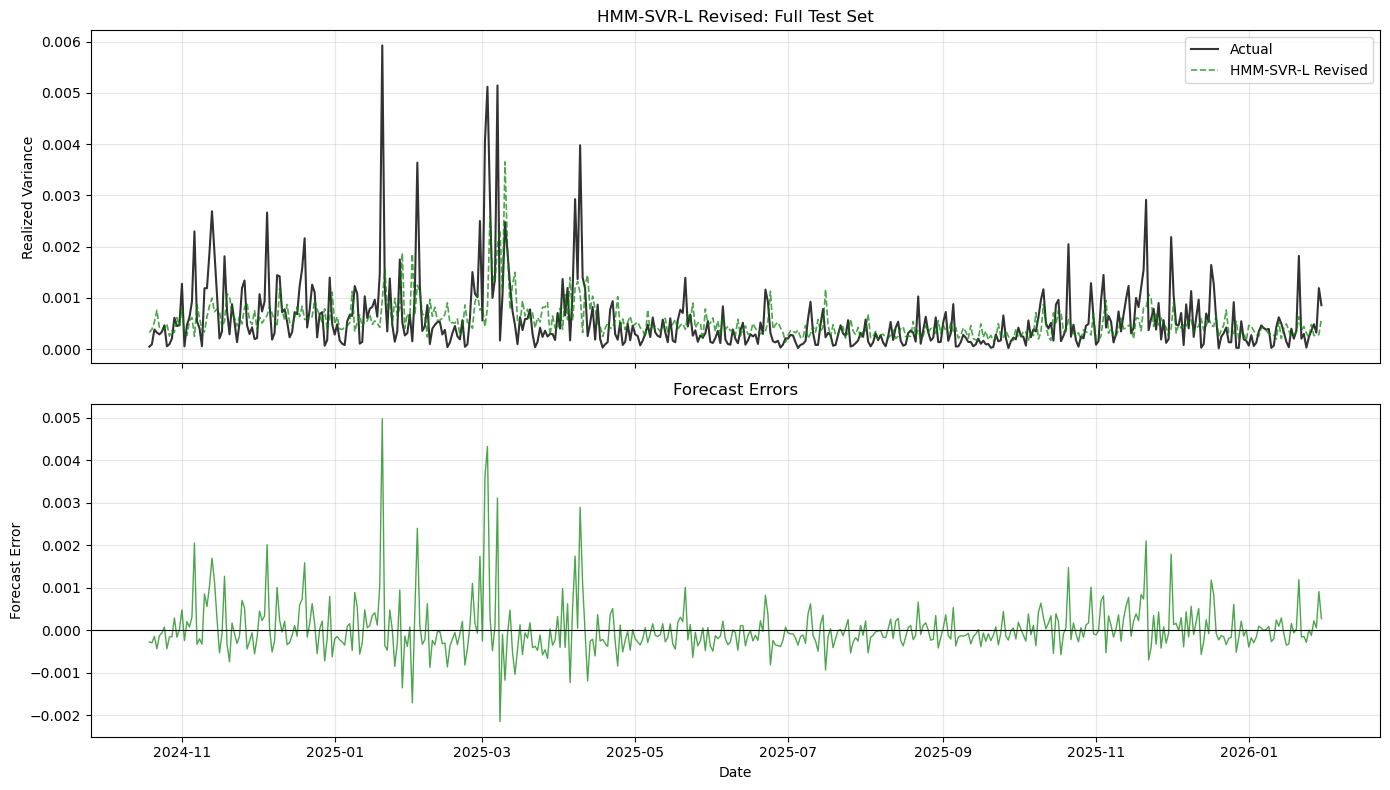

In [ ]:
plot_df = test_results.copy()
plot_df['date'] = pd.to_datetime(plot_df['date'])
plot_df = plot_df.sort_values('date').reset_index(drop=True)

plot_dates = plot_df['date'].to_numpy()
plot_actuals = plot_df['actual'].to_numpy()
plot_forecasts = plot_df['forecast'].to_numpy()
plot_errors = plot_df['error'].to_numpy()

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# Panel 1: Actual vs Forecast
axes[0].plot(plot_dates, plot_actuals, label='Actual', color='black', linewidth=1.5, alpha=0.8)
axes[0].plot(plot_dates, plot_forecasts, label='HMM-SVR-L Revised', color='green', linewidth=1.2, alpha=0.7, linestyle='--')
axes[0].set_ylabel('Realized Variance')
axes[0].set_title('HMM-SVR-L Revised: Full Test Set')
axes[0].legend(loc='upper right')
axes[0].grid(True, alpha=0.3)

# Panel 2: Forecast Errors
axes[1].plot(plot_dates, plot_errors, color='green', linewidth=1, alpha=0.7)
axes[1].axhline(y=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_ylabel('Forecast Error')
axes[1].set_xlabel('Date')
axes[1].set_title('Forecast Errors')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


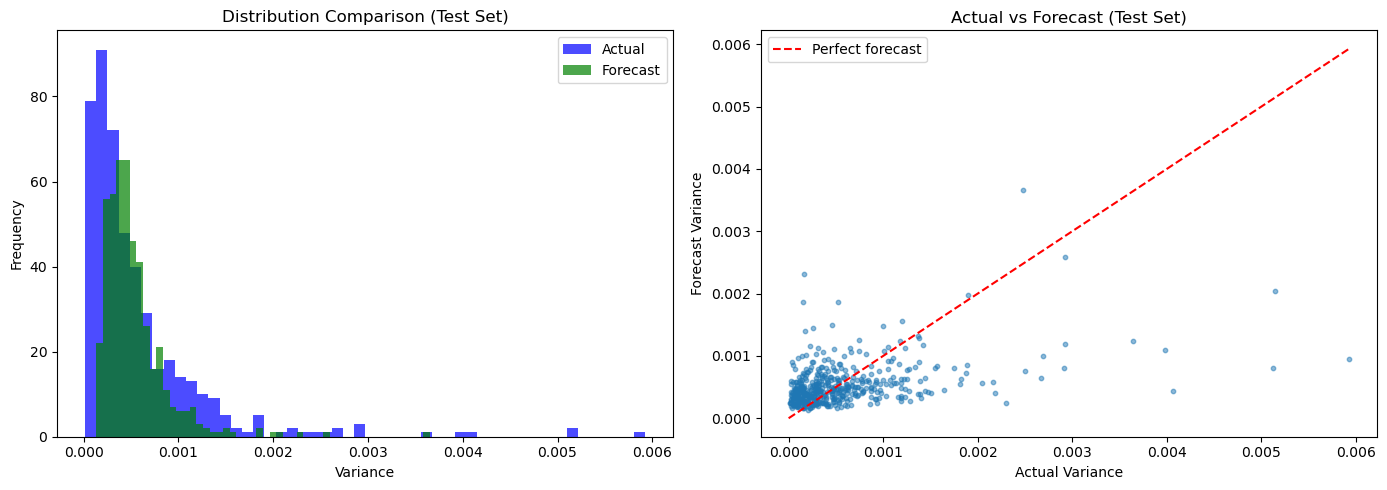


Forecast Statistics (Test Set):
  Mean forecast: 0.000533
  Mean actual:   0.000569
  Forecast std:  0.000344
  Actual std:    0.000689
  Forecasts > Actuals: 58.2%


In [44]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution comparison
axes[0].hist(plot_actuals, bins=50, alpha=0.7, label='Actual', color='blue')
axes[0].hist(plot_forecasts, bins=50, alpha=0.7, label='Forecast', color='green')
axes[0].set_xlabel('Variance')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution Comparison (Test Set)')
axes[0].legend()

# Actual vs Forecast scatter
axes[1].scatter(plot_actuals, plot_forecasts, alpha=0.5, s=10)
max_val = max(plot_actuals.max(), plot_forecasts.max())
axes[1].plot([0, max_val], [0, max_val], 'r--', label='Perfect forecast')
axes[1].set_xlabel('Actual Variance')
axes[1].set_ylabel('Forecast Variance')
axes[1].set_title('Actual vs Forecast (Test Set)')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nForecast Statistics (Test Set):")
print(f"  Mean forecast: {plot_forecasts.mean():.6f}")
print(f"  Mean actual:   {plot_actuals.mean():.6f}")
print(f"  Forecast std:  {plot_forecasts.std():.6f}")
print(f"  Actual std:    {plot_actuals.std():.6f}")
print(f"  Forecasts > Actuals: {(plot_forecasts > plot_actuals).mean()*100:.1f}%")
